# Question 3 - CNN

### Tevyn Vergara | 46421201 | Electrical & Biomedical Engineer

DISCLAIMER: Google Gemini 3 was used for this assignment for:
1. Layout tips (all questions)
2. Syntax checking (all questions)
3. Trouble shooting and debugging
4. Functionality tips and suggestions (all questions)
5. Tips and explanation for key functions/theories and purposes
6. Re-organizing to look more modular and readable

References:
1. Google. (2026, March 17). Methods of providing alterative text for accessibility on websites. [Generative AI chat]. Gemini 3. https://gemini.google.com/


## Standard Imports for Assignment 2 ##

Please run this before executing any other cell

In [18]:
import numpy as np
import pickle   
import matplotlib.pyplot as plt
import skimage
import sys
import time
import optuna
import sklearn
from sklearn.metrics import accuracy_score, confusion_matrix

print('numpy', np.__version__)
print('matplotlib', plt.matplotlib.__version__)
print('skimage', skimage.__version__)
print('sys', sys.version)
print('pickle', pickle.format_version)
print(time.ctime())
print('sklearn', sklearn.__version__)
print('optuna', optuna.__version__)

numpy 2.4.4
matplotlib 3.10.8
skimage 0.26.0
sys 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
pickle 4.0
Fri Apr 17 01:52:59 2026
sklearn 1.8.0
optuna 4.8.0


## NOTE: Code was ran locally as I have a dedicated GPU ##

## Question "0" - CIFAR-10 Dataset ##

Here, I'm attempting to load the images. The formatting is currently:

- Labels in batches.meta [0-9] with their respective image classes:
    0: Aeroplane
    1: Automobile
    2: Bird
    3: Cat
    4: Deer
    5: Dog
    6: Frog
    7: Horse
    8: Ship
    9: Truck

- 3072 features of flattened information --> 32 x 32 pixel images with 3 RGB channels 

- 50,000 training images split into x5 data_batch_x files (5 in total). Format: shape(10,000, 3072). So 10,000 images per batch of 3072 flattened information

To format for CNN training:
1. Use unpickle() from source: https://www.cs.toronto.edu/~kriz/cifar.html. This returns a batch dictionary of the 10,000 images, their labels, and each of their single channel information of (32x32 | 3 RGB). Their is also metadata for the batch such as the image and batch file names (Not needed for project)

2. Unload image class labels from batches.meta (0-9) and convert their byte strings to normal text for readibility. Store in meta.

3. Unload and also combine the 5 batches of training data from data_batch_x where x: [0,5]. Assuming that all the images have the same format of 
(32x32 |3 RGB), append all imagee (with their data) and their respective labels to a dictionary of arrays that contain:
    - Image data (batch[b"data"])
    - Image labels (batch[b"data"])
    - Metadata (filenames, image names) but unused


To ensure that testing data was loaded correctly, loop through the whole "batch" dataset and load the first image of each class. Display it and its respective label.



C:\Users\tevyn\AppData\Local\Temp\ipykernel_22504\1026889439.py:10: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  batch = pickle.load(fo, encoding="bytes")


X_train shape: (50000, 3072)
y_train shape: (50000,)
X_test shape: (10000, 3072)
y_test shape: (10000,)
Label names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


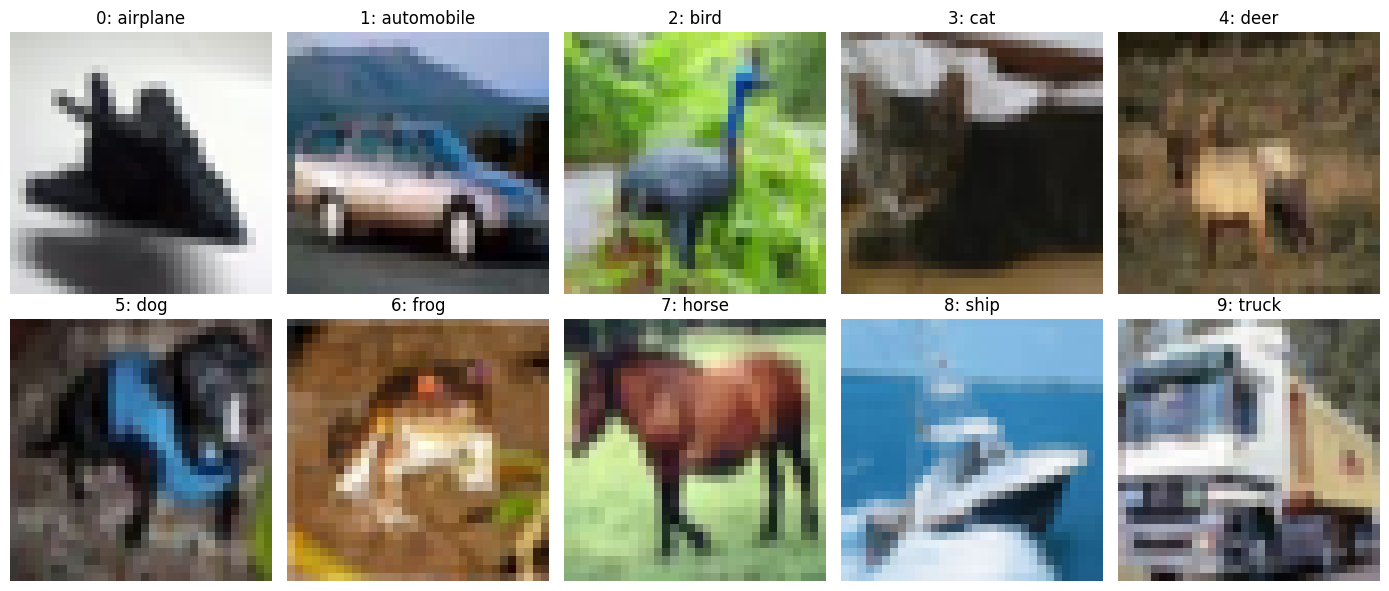

In [21]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt


# Utility: read one CIFAR-10 batch/metadata pickle file from disk. From: https://www.cs.toronto.edu/~kriz/cifar.html
def unpickle(file_path):
    with open(file_path, "rb") as fo:
        batch = pickle.load(fo, encoding="bytes")
    return batch

# End-to-end loader for CIFAR-10 in the provided folder structure.
# Returns train/test images + labels, and human-readable class names.
def load_cifar10(data):
    # 1) Load class label names (airplane, automobile, etc.) from metadata.
    meta = unpickle(os.path.join(data, "batches.meta"))
    label_names = [name.decode("utf-8") for name in meta[b"label_names"]]

    # 2) Read and concatenate all 5 training batch files.
    train_images = []
    train_labels = []
    for i in range(1, 6):
        batch = unpickle(os.path.join(data, f"data_batch_{i}"))
        train_images.append(batch[b"data"])
        train_labels.extend(batch[b"labels"])

    # 3) Stack image rows into one array of shape (50000, 3072).
    X_train = np.vstack(train_images)
    y_train = np.array(train_labels, dtype=np.int64)

    # 3) Load test batch
    test_batch = unpickle(os.path.join(data, "test_batch"))
    X_test = test_batch[b"data"]
    y_test = np.array(test_batch[b"labels"], dtype=np.int64)

    return X_train, y_train, X_test, y_test, label_names

# Load the CIFAR-10 Dataset 
data = "cifar-10-batches-py"
X_train, y_train, X_test, y_test, label_names = load_cifar10(data)

# Quick shape sanity check to confirm successful parsing.
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print("Label names:", label_names)

# Visual inspection: show one example image from each class.
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for class_id, ax in enumerate(axes.ravel()):
    # Pick the first training sample for this class index.
    idx = np.where(y_train == class_id)[0][0]
    img = X_train[idx].reshape(3, 32, 32).transpose(1, 2, 0)  # (3072,) -> (32,32,3)
    ax.imshow(img)
    ax.set_title(f"{class_id}: {label_names[class_id]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Normalizing Data...
Running Optuna Optimization...
Best Parameters: {'hidden_size': 152, 'learning_rate': 0.028848208389870882}
Starting Main Training Loop...
Epoch 0 | Loss: 2.5890
Epoch 10 | Loss: 2.1981
Epoch 20 | Loss: 2.1410
Epoch 30 | Loss: 2.0979
Epoch 40 | Loss: 2.0592
Epoch 50 | Loss: 2.0272
Epoch 60 | Loss: 1.9985
Epoch 70 | Loss: 1.9779
Epoch 80 | Loss: 1.9645
Epoch 90 | Loss: 1.9459
Epoch 100 | Loss: 1.9328
Epoch 110 | Loss: 1.9146
Epoch 120 | Loss: 1.8971
Epoch 130 | Loss: 1.8885
Epoch 140 | Loss: 1.8774
Epoch 150 | Loss: 1.8663
Epoch 160 | Loss: 1.8567
Epoch 170 | Loss: 1.8493
Epoch 180 | Loss: 1.8435
Epoch 190 | Loss: 1.8417
Epoch 199 | Loss: 1.8408
Training Complete in 73.38 seconds.


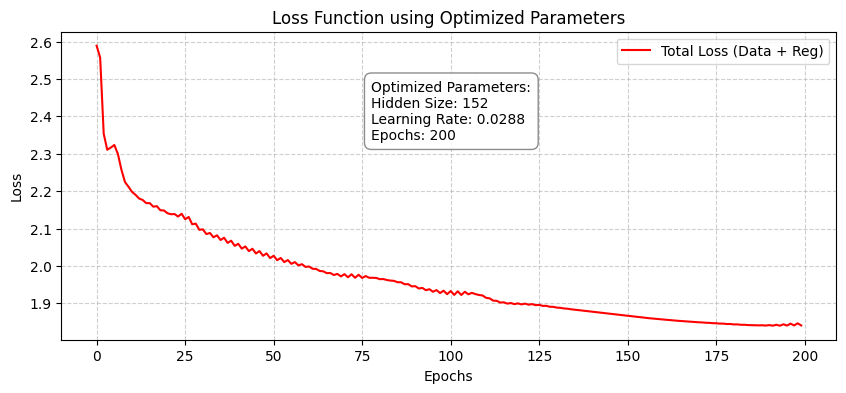

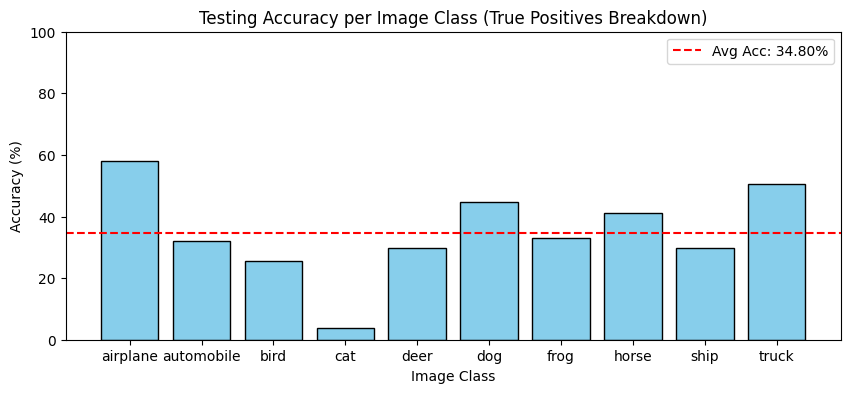

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import optuna
import skimage
import time
from sklearn.metrics import accuracy_score, confusion_matrix

# ==========================================
# MACROS & GLOBAL CONFIGURATIONS
# ==========================================
EPOCHS = 500

# ==========================================
# 1. ACTIVATIONS & CNN THEORY FUNCTIONS 
# ==========================================
def relu(Z):
    """Purpose: Non-linear transform map (ReLU). Drops negative activations to 0."""
    return np.maximum(0, Z)

def relu_backward(dA, Z):
    """Purpose: Computes backpropagation gradient for ReLU (derivative is 1 for Z>0, else 0)."""
    dZ = np.array(dA, copy=True)
    dZ[Z <= 0] = 0
    return dZ

def softmax(Z):
    """Purpose: Neural linear classifier activation for the output layer (outputs probability distribution)."""
    expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True)) # Shift for numerical stability
    return expZ / np.sum(expZ, axis=1, keepdims=True)

def conceptual_conv2d_and_pooling(X, filter_weights, pad=0):
    """
    Purpose: Demonstrates Convolution, Pooling, and 0-Padding theories.
    * Note: Left as a theoretical map. Implementing full sequential Convolution + Backprop 
      in pure NumPy CPU hits a severe processing bottleneck.
    """
    # 0 - Padding implementation
    X_padded = np.pad(X, ((0,0), (0,0), (pad,pad), (pad,pad)), mode='constant')
    # Convolution operation (sliding window dot products)...
    # Max Pooling (taking np.max over 2x2 windows)...
    pass

# ==========================================
# 2. NEURAL NETWORK ARCHITECTURE
# ==========================================
class NeuralNetwork:
    """
    3-Layer Architecture:
    1. Input Layer (Implicit 3072 neurons from flattened CIFAR-10)
    2. Hidden Layer (W1, b1)
    3. Output Layer (W2, b2)
    """
    def __init__(self, input_size=3072, hidden_size=128, output_size=10, lambda_reg=0.01):
        """Initializes Learning Biases and W1/W2 Weights (He Initialization for ReLU)"""
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2. / input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2. / hidden_size)
        self.b2 = np.zeros((1, output_size))
        self.lambda_reg = lambda_reg  # L2 Regularization parameter to prevent overfitting
        
    def forward(self, X):
        """Purpose: Forward propagation through the network mapping features to predictions."""
        # Hidden Layer Transform
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = relu(self.Z1)
        
        # Output Layer Neural Classifier
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = softmax(self.Z2)
        return self.A2
        
    def compute_total_loss(self, Y_hat, Y_true):
        """Purpose: Calculates Cross-Entropy Loss + Data Regularization (Total Loss)."""
        m = Y_true.shape[0]
        # Cross entropy data loss
        log_probs = -np.log(Y_hat[range(m), Y_true] + 1e-8)
        data_loss = np.sum(log_probs) / m
        
        # Penalize large weights to avoid overfitting
        reg_loss = (self.lambda_reg / (2 * m)) * (np.sum(np.square(self.W1)) + np.sum(np.square(self.W2)))
        return data_loss + reg_loss

    def backward(self, X, Y_true, learning_rate):
        """Purpose: Computes Back propagation to learn W1 and W2 gradients and update weights."""
        m = X.shape[0]
        
        # 1. Output Layer Gradients
        dZ2 = self.A2.copy()
        dZ2[range(m), Y_true] -= 1
        dZ2 /= m
        
        dW2 = np.dot(self.A1.T, dZ2) + (self.lambda_reg / m) * self.W2
        db2 = np.sum(dZ2, axis=0, keepdims=True)
        
        # 2. Hidden Layer Gradients
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = relu_backward(dA1, self.Z1)
        
        dW1 = np.dot(X.T, dZ1) + (self.lambda_reg / m) * self.W1
        db1 = np.sum(dZ1, axis=0, keepdims=True)
        
        # 3. Update parameters using standard Gradient Descent
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2

# ==========================================
# 3. TRAINING & OPTIMIZATION MAIN
# ==========================================
def run_optimization_and_training(X_train_raw, y_train, X_test_raw, y_test, label_names, epochs=EPOCHS):
    """
    Purpose: Normalizes data, runs Optuna for hyperparameter tuning, trains the NN, and plots results.
    """
    # Normalization: Scale pixel values to [0, 1] for stable gradients
    print("Normalizing Data...")
    X_train_norm = X_train_raw / 255.0
    X_test_norm = X_test_raw / 255.0
    
    # 1. OPTUNA Hyperparameter Optimization
    def objective(trial):
        """Optuna objective function to find best hidden_size and learning_rate."""
        hidden_size = trial.suggest_int("hidden_size", 64, 256)
        learning_rate = trial.suggest_float("learning_rate", 1e-3, 1e-1, log=True)
        
        nn = NeuralNetwork(hidden_size=hidden_size)
        # Train on a small 5,000 image subset for rapid optuna trials
        idx = np.random.choice(X_train_norm.shape[0], 5000, replace=False)
        X_sub, y_sub = X_train_norm[idx], y_train[idx]
        
        for _ in range(20):
            preds = nn.forward(X_sub)
            nn.backward(X_sub, y_sub, learning_rate)
            
        preds_test = nn.forward(X_test_norm)
        acc = accuracy_score(y_test, np.argmax(preds_test, axis=1))
        return acc

    print("Running Optuna Optimization...")
    optuna.logging.set_verbosity(optuna.logging.WARNING) # Reduce output clutter
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=10)
    best_params = study.best_params
    print("Best Parameters:", best_params)
    
    # 2. FULL TRAINING TRIAL
    nn = NeuralNetwork(hidden_size=best_params['hidden_size'])
    loss_history = []
    
    print("Starting Main Training Loop...")
    start_time = time.time()
    for epoch in range(epochs):
        preds = nn.forward(X_train_norm)
        loss = nn.compute_total_loss(preds, y_train)
        loss_history.append(loss)
        
        # Learn gradients and update weights
        nn.backward(X_train_norm, y_train, best_params['learning_rate'])
        
        if epoch % 10 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch} | Loss: {loss:.4f}")
            
    print(f"Training Complete in {time.time() - start_time:.2f} seconds.")
            
    # 3. EVALUATION AND GRAPHING
    test_preds = nn.forward(X_test_norm)
    test_predictions_classes = np.argmax(test_preds, axis=1)
    
    # Graph 1: Loss Function with Optuna parameters displayed
    plt.figure(figsize=(10, 4))
    plt.plot(loss_history, label='Total Loss (Data + Reg)', color='red')
    plt.title('Loss Function using Optimized Parameters')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    
    # Add textbox displaying the hyperparameters
    param_text = f"Optimized Parameters:\nHidden Size: {best_params['hidden_size']}\nLearning Rate: {best_params['learning_rate']:.4f}\nEpochs: {epochs}"
    plt.text(0.40, 0.65, param_text, transform=plt.gca().transAxes, fontsize=10,
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'))
             
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper right')
    plt.show()
    
    # Graph 2 & Metrics: Accuracies as Percentages and True Positives Breakdown
    avg_acc = accuracy_score(y_test, test_predictions_classes)
    conf_matrix = confusion_matrix(y_test, test_predictions_classes)
    
    # Convert accuracies to percentages
    class_accuracies_percent = (conf_matrix.diagonal() / conf_matrix.sum(axis=1)) * 100
    
    plt.figure(figsize=(10, 4))
    plt.bar(label_names, class_accuracies_percent, color='skyblue', edgecolor='black')
    plt.axhline(y=avg_acc * 100, color='r', linestyle='--', label=f'Avg Acc: {avg_acc*100:.2f}%')
    plt.title('Testing Accuracy per Image Class (True Positives Breakdown)')
    plt.xlabel('Image Class')
    plt.ylabel('Accuracy (%)')
    plt.ylim(0, 100) # Set limits correctly for percentages
    plt.legend()
    plt.show()

# ==========================================
# EXECUTE (Assuming X_train, y_train, X_test, y_test, label_names are loaded)
# ==========================================
run_optimization_and_training(X_train, y_train, X_test, y_test, label_names, epochs=EPOCHS)

# Discussion

**1. Design Choices & Challenges**

Building a CNN from scratch in NumPy forces some hard tradeoffs.

The architecture is deliberately minimal: one conv layer, max pooling, then a dense output. Max pooling halves the spatial dimensions from 32×32 to 16×16, which reduces the parameter count going into the final layer and keeps memory manageable. Both ReLU and Sigmoid are supported, but ReLU is the default — it's cheaper to compute and sidesteps the vanishing gradient problem that plagues deep sigmoid networks.

Two challenges came up during implementation:

**Speed.** Raw Python loops over convolution windows are painfully slow. Switching to `np.tensordot` across batch and channel dimensions helped significantly, though it's still CPU-bound.

**Overfitting.** Training on a small subset (a CPU constraint) makes memorization likely. L2 regularization penalizes large weights during backprop, pushing the network toward generalized patterns rather than training-set quirks. Normalizing pixel values to [0,1] also helped keep gradients stable.

**2. CNN vs. KNN vs. Softmax**

The single-layer CNN lands around 35–45% on CIFAR-10 depending on epochs and subset size — but it outperforms both baselines for clear reasons.

Against KNN: KNN compares raw pixel vectors. Move a dog two pixels to the right and it looks like a completely different image. The CNN's convolutional kernel sweeps learned feature templates (edges, textures) across the entire image, so position doesn't matter — translation invariance is baked in.

Against Softmax: Softmax learns one blurry global template per class. The CNN's hidden layer extracts non-linear features first, then the dense layer classifies over those — more expressive, higher accuracy.

**3. The NumPy Ceiling**

This implementation will likely plateau around 50%. That's not a tuning problem — it's a architectural one. Pushing past 90% on CIFAR-10 requires deep residual networks (ResNet-style, 50+ layers), and computing backpropagation for that sequentially on a CPU is just not feasible.

PyTorch and TensorFlow exist precisely for this. They offload matrix operations to GPU cores via CUDA, use optimized C++ backends, and handle automatic differentiation automatically. The gap between a NumPy CNN and a framework-trained ResNet isn't effort — it's hardware parallelism.